# Combined Hybrid Open-Set Active Learning: MLP vs Random Forest vs XGBoost

This notebook runs the **same Active Learning experiment** for three base models:

1. **MLP**
2. **Random Forest**
3. **XGBoost**

The goal is a fair cross-model comparison of the complete Hybrid Open-Set pipeline.

## Fair-comparison guarantees

The following are identical across all three models:

- Same polished ICS-NAD dataset.
- Same 86 approved behavior features.
- Same `split_A_comparable` train/validation/test split.
- Same hidden classes: `land`, `ackpflood`, `teardrop`.
- Same seeds: 42, 2026, 31415.
- Same initial labeled indices for each seed.
- Same 50 initial labeled examples per known class.
- Same 300-label Active Learning budget.
- Same query batch size = 25.
- Same Hybrid quotas: uncertainty 8, novelty 7, expansion 7, random exploration 3.
- Same diversity thresholds.
- Same analyst-feedback simulation.
- Same final sealed test set.
- Same Version-B source-file-disjoint external benchmark.

## Strategies evaluated per model

Each model runs:

- `random`
- `uncertainty`
- `hybrid_open_set`

Therefore research mode runs:

**3 models × 3 strategies × 3 seeds = 27 full Active Learning runs**

plus separate Version-B external evaluations.

## Important representation note

The acquisition logic is the same, but each model necessarily provides its own model-space representation:

- MLP → learned signed latent embedding.
- Random Forest → signed centered log-probability representation.
- XGBoost → signed raw-margin representation.

For that reason, cross-model redundancy values should be interpreted as **model-specific diversity indicators**, while UADR, discovery cost, query yield, Macro-F1, recall, accuracy, ACK-pair metrics, and external Macro-F1 are directly comparable.

## Repository execution

This GitHub-ready version uses repository-relative paths. Keep the supplied
`data/` and `reports/` folders beside `notebooks/`. Generated experiment
artifacts are written to:

`results/combined_hybrid_open_set_mlp_rf_xgb/`


In [ ]:
# ============================================================
# 1. Imports, repository-relative paths, reproducibility
# ============================================================
from pathlib import Path
import os, json, math, random, copy, shutil, warnings, time, gc
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import xgboost as xgb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Repository root detection
# Works when Jupyter is started from either:
#   1) the repository root, or
#   2) the notebooks/ directory.
# ------------------------------------------------------------
CWD = Path.cwd().resolve()
candidate_roots = [CWD, CWD.parent]

REPO_ROOT = None
for candidate in candidate_roots:
    if (
        (candidate / "data" / "feature_spec_v3.json").exists()
        and (candidate / "data" / "data_readiness_summary.json").exists()
    ):
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Repository root could not be detected. "
        "Start Jupyter from the repository root or from the notebooks/ directory."
    )

DATA_DIR = REPO_ROOT / "data"
REPORT_DIR = REPO_ROOT / "reports"
WORK_ROOT = REPO_ROOT / "results"

PATHS = {
    "readiness": DATA_DIR / "data_readiness_summary.json",
    "model_csv": DATA_DIR / "ics_nad_model_table_v3.csv",  # optional fallback; not required
    "model_parquet": DATA_DIR / "ics_nad_model_table_v3.parquet",
    "feature_spec": DATA_DIR / "feature_spec_v3.json",
    "capture_coverage": REPORT_DIR / "class_capture_coverage.csv",
    "manual_review": REPORT_DIR / "manual_label_review.csv",
    "split_A_counts": REPORT_DIR / "version_A_comparable_class_counts.csv",
    "split_B_counts": REPORT_DIR / "version_B_class_counts.csv",
    "split_B_diag": REPORT_DIR / "version_B_external_diagnostic.csv",
}

def resolve_path(key):
    path = PATHS[key]
    if path.exists():
        return path
    return path

OUTPUT_DIR = WORK_ROOT / "combined_hybrid_open_set_mlp_rf_xgb"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(exist_ok=True)
(OUTPUT_DIR / "per_run").mkdir(exist_ok=True)
(OUTPUT_DIR / "audit").mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Torch device:", DEVICE)
print("Repository root:", REPO_ROOT)
print("Dataset:", PATHS["model_parquet"])
print("Output directory:", OUTPUT_DIR)


In [2]:
# ============================================================
# 2. Frozen experiment configuration
# ============================================================

RUN_MODE = "research"   # use "smoke" only to test the notebook

MODELS = ["MLP", "RandomForest", "XGBoost"]
STRATEGIES = ["random", "uncertainty", "hybrid_open_set"]

if RUN_MODE == "research":
    EXPERIMENT_SEEDS = [42, 2026, 31415]
    INITIAL_PER_KNOWN_CLASS = 50
    LABEL_BUDGET = 300
    QUERY_BATCH_SIZE = 25

    CANDIDATE_OVERSAMPLE = 20
    DENSITY_REFERENCE_SIZE = 4000
    DENSITY_K = 10

    MLP_MAX_EPOCHS = 50
    MLP_PATIENCE = 6
    MLP_MC_PASSES = 15

    RF_N_ESTIMATORS = 300
    XGB_N_ESTIMATORS = 250
else:
    EXPERIMENT_SEEDS = [42]
    INITIAL_PER_KNOWN_CLASS = 8
    LABEL_BUDGET = 25
    QUERY_BATCH_SIZE = 5

    CANDIDATE_OVERSAMPLE = 4
    DENSITY_REFERENCE_SIZE = 500
    DENSITY_K = 5

    MLP_MAX_EPOCHS = 4
    MLP_PATIENCE = 2
    MLP_MC_PASSES = 3

    RF_N_ESTIMATORS = 40
    XGB_N_ESTIMATORS = 30

# ---------------- MLP ----------------
MLP_HIDDEN_UNITS = (256, 128)
MLP_EMBEDDING_DIM = 64
MLP_DROPOUT = 0.25
MLP_LR = 1e-3
MLP_WEIGHT_DECAY = 1e-4
MLP_TRAIN_BATCH_SIZE = 256
MLP_FOCAL_GAMMA = 1.0
MLP_GRAD_CLIP = 5.0

# ---------------- Random Forest ----------------
RF_MAX_DEPTH = None
RF_MIN_SAMPLES_SPLIT = 2
RF_MIN_SAMPLES_LEAF = 1
RF_MAX_FEATURES = "sqrt"
RF_BOOTSTRAP = True
RF_MAX_SAMPLES = None
RF_CRITERION = "gini"

# ---------------- XGBoost ----------------
XGB_MAX_DEPTH = 6
XGB_LEARNING_RATE = 0.05
XGB_SUBSAMPLE = 0.90
XGB_COLSAMPLE_BYTREE = 0.90
XGB_MIN_CHILD_WEIGHT = 1.0
XGB_REG_ALPHA = 0.0
XGB_REG_LAMBDA = 1.0
XGB_GAMMA = 0.0

# Same class-weighting policy for all models.
EFFECTIVE_NUMBER_BETA = 0.999
MAX_CLASS_WEIGHT = 4.0

# Same Hybrid acquisition policy for all models.
HYBRID_QUOTAS = {
    "uncertainty": 8,
    "novelty": 7,
    "expansion": 7,
    "random": 3,
}

STRICT_COSINE_SIM_THRESHOLD = 0.60
RELAXED_SIM_THRESHOLDS = [0.60, 0.70, 0.80, 0.90, 1.01]

BASE_W_UNCERTAINTY = 0.40
BASE_W_NOVELTY = 0.40
BASE_W_DENSITY = 0.20

EVALUATE_TEST_EACH_ROUND = False
RUN_EXTERNAL_CAPTURE_BENCHMARK = True
RESUME_COMPLETED_RUNS = True

assert sum(HYBRID_QUOTAS.values()) == 25
assert QUERY_BATCH_SIZE == 25 or RUN_MODE == "smoke"

print({
    "run_mode": RUN_MODE,
    "models": MODELS,
    "strategies": STRATEGIES,
    "seeds": EXPERIMENT_SEEDS,
    "initial_per_known_class": INITIAL_PER_KNOWN_CLASS,
    "label_budget": LABEL_BUDGET,
    "query_batch_size": QUERY_BATCH_SIZE,
})

{'run_mode': 'research', 'models': ['MLP', 'RandomForest', 'XGBoost'], 'strategies': ['random', 'uncertainty', 'hybrid_open_set'], 'seeds': [42, 2026, 31415], 'initial_per_known_class': 50, 'label_budget': 300, 'query_batch_size': 25}


In [3]:
# ============================================================
# 3. Load manifests and validate experiment specification
# ============================================================

with open(resolve_path("readiness"), "r", encoding="utf-8") as f:
    readiness = json.load(f)

with open(resolve_path("feature_spec"), "r", encoding="utf-8") as f:
    feature_spec = json.load(f)

TARGET = feature_spec["target_column"]
BINARY_TARGET = feature_spec["binary_target_column"]
BENIGN_CLASS = feature_spec["benign_class"]
HIDDEN_CLASSES = list(feature_spec["hidden_classes"])
BEHAVIOR_FEATURES = list(feature_spec["behavior_features"])
NUMERIC_FEATURES = list(feature_spec["numeric_model_features"])
CATEGORICAL_FEATURES = list(feature_spec["categorical_model_features"])
FORBIDDEN_PREDICTORS = set(feature_spec["forbidden_predictors"])
QUERY_GROUP_COL = feature_spec["active_learning_query_group_column"]
PRIMARY_SPLIT = feature_spec["recommended_primary_split"]
TEMPORAL_SPLIT = feature_spec["recommended_robustness_split"]
EXTERNAL_SPLIT = feature_spec["external_capture_split_column"]

assert HIDDEN_CLASSES == ["land", "ackpflood", "teardrop"]
assert len(BEHAVIOR_FEATURES) == readiness["behavior_features"] == 86
assert set(BEHAVIOR_FEATURES).isdisjoint(FORBIDDEN_PREDICTORS)
assert QUERY_GROUP_COL not in BEHAVIOR_FEATURES

for key in ["readiness", "feature_spec", "capture_coverage", "manual_review", "split_A_counts", "split_B_counts", "split_B_diag"]:
    p = resolve_path(key)
    if p.exists():
        shutil.copy2(p, OUTPUT_DIR / "audit" / p.name)

print("Rows expected:", readiness["rows"])
print("Classes expected:", readiness["classes"])
print("Behavior features:", len(BEHAVIOR_FEATURES))
print("Hidden classes:", HIDDEN_CLASSES)
print("Primary split:", PRIMARY_SPLIT)
print("External split:", EXTERNAL_SPLIT)

Rows expected: 67801
Classes expected: 17
Behavior features: 86
Hidden classes: ['land', 'ackpflood', 'teardrop']
Primary split: split_A_comparable
External split: split_B_external


In [4]:
# ============================================================
# 4. Load polished model table
# ============================================================

model_parquet = resolve_path("model_parquet")
model_csv = resolve_path("model_csv")

model_df = None
loaded_from = None

if model_parquet.exists():
    try:
        model_df = pd.read_parquet(model_parquet)
        loaded_from = model_parquet
    except Exception:
        pass

if model_df is None:
    if not model_csv.exists():
        raise FileNotFoundError("Polished model table was not found.")
    model_df = pd.read_csv(model_csv, low_memory=False)
    loaded_from = model_csv

required_cols = set(BEHAVIOR_FEATURES) | {
    TARGET, BINARY_TARGET, QUERY_GROUP_COL,
    PRIMARY_SPLIT, TEMPORAL_SPLIT, EXTERNAL_SPLIT,
    "row_uid", "source_file",
}

missing = sorted(required_cols - set(model_df.columns))
assert not missing, f"Missing required columns: {missing}"

assert len(model_df) == readiness["rows"] == 67801
assert model_df[TARGET].nunique() == readiness["classes"] == 17

ALL_CLASSES = sorted(model_df[TARGET].astype(str).unique().tolist())
KNOWN_CLASSES = [c for c in ALL_CLASSES if c not in HIDDEN_CLASSES]

primary_train_df = model_df[model_df[PRIMARY_SPLIT].eq("train")].reset_index(drop=True)
primary_val_df = model_df[model_df[PRIMARY_SPLIT].eq("validation")].reset_index(drop=True)
primary_test_df = model_df[model_df[PRIMARY_SPLIT].eq("test")].reset_index(drop=True)

b_dev = model_df[model_df[EXTERNAL_SPLIT].eq("development")]
b_ext = model_df[model_df[EXTERNAL_SPLIT].eq("external_test")]

assert set(b_dev["source_file"]).isdisjoint(set(b_ext["source_file"]))

print("Loaded:", loaded_from)
print("Shape:", model_df.shape)
print("Known classes:", len(KNOWN_CLASSES))
print("Hidden classes:", HIDDEN_CLASSES)
print("\nPrimary split sizes:")
display(model_df[PRIMARY_SPLIT].value_counts().rename("rows").to_frame())
print("\nPrimary class counts:")
display(pd.crosstab(model_df[TARGET], model_df[PRIMARY_SPLIT]))
print(
    f"Version-B source files: development={b_dev['source_file'].nunique()}, "
    f"external={b_ext['source_file'].nunique()}, overlap=0"
)

Loaded: /kaggle/input/datasets/ericroy519/final-ics-2-0919/datasets/ics_nad_model_table_v3.parquet
Shape: (67801, 102)
Known classes: 14
Hidden classes: ['land', 'ackpflood', 'teardrop']

Primary split sizes:


,rows
split_A_comparable,
train,47462
test,13560
validation,6779



Primary class counts:


split_A_comparable,test,train,validation
attack_type,,,
ackflood,1000,3500,500
ackpflood,199,698,100
benign,1000,3500,500
fraggle,1000,3500,500
icmpbig,967,3383,483
icmpflood,1000,3500,500
land,464,1626,232
pingofdeath,1000,3500,500
routeip,935,3272,467


Version-B source files: development=31, external=17, overlap=0


In [5]:
# ============================================================
# 5. One shared leakage-safe preprocessing pipeline
# ============================================================

def make_preprocessor():
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot),
    ])

    return ColumnTransformer(
        [
            ("num", numeric_pipe, NUMERIC_FEATURES),
            ("cat", categorical_pipe, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )

def transform_dense(preprocessor, frame):
    X = preprocessor.transform(frame[BEHAVIOR_FEATURES])
    X = np.asarray(X, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=10.0, neginf=-10.0)
    return np.clip(X, -10.0, 10.0)

# Fits only to primary TRAIN features; no validation/test fitting.
preprocessor = make_preprocessor()
preprocessor.fit(primary_train_df[BEHAVIOR_FEATURES])

X_train = transform_dense(preprocessor, primary_train_df)
X_val = transform_dense(preprocessor, primary_val_df)
X_test = transform_dense(preprocessor, primary_test_df)

feature_names = preprocessor.get_feature_names_out().tolist()
pd.Series(feature_names, name="feature").to_csv(
    OUTPUT_DIR / "preprocessed_feature_names.csv", index=False
)

assert np.isfinite(X_train).all()
assert np.isfinite(X_val).all()
assert np.isfinite(X_test).all()

print("Shared model input dimension:", X_train.shape[1])
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Shared model input dimension: 133
Train: (47462, 133)
Validation: (6779, 133)
Test: (13560, 133)


In [6]:
# ============================================================
# 6. Common utilities and class weighting
# ============================================================

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def effective_number_weights(counts, beta=EFFECTIVE_NUMBER_BETA):
    counts = np.asarray(counts, dtype=np.float64)
    counts = np.maximum(counts, 1.0)

    effective = (1.0 - np.power(beta, counts)) / (1.0 - beta)
    weights = 1.0 / np.maximum(effective, 1e-12)

    weights = weights / np.mean(weights)
    weights = np.clip(weights, 0.5, MAX_CLASS_WEIGHT)

    return weights.astype(np.float32)

def rank01(x):
    x = np.asarray(x, dtype=np.float64)
    n = len(x)

    if n <= 1:
        return np.zeros(n, dtype=np.float32)

    order = np.argsort(x, kind="mergesort")
    ranks = np.empty(n, dtype=np.float64)
    ranks[order] = np.linspace(0.0, 1.0, n)
    return ranks.astype(np.float32)

def l2_normalize_rows(z):
    z = np.asarray(z, dtype=np.float32)
    norms = np.linalg.norm(z, axis=1, keepdims=True)
    return z / np.maximum(norms, 1e-12)

In [7]:
# ============================================================
# 7. MLP model, representation, uncertainty
# ============================================================

class OpenSetMLP(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()

        self.feature_net = nn.Sequential(
            nn.Linear(input_dim, MLP_HIDDEN_UNITS[0]),
            nn.ReLU(),
            nn.Dropout(MLP_DROPOUT),
            nn.Linear(MLP_HIDDEN_UNITS[0], MLP_HIDDEN_UNITS[1]),
            nn.ReLU(),
            nn.Dropout(MLP_DROPOUT),
        )

        self.projection = nn.Linear(MLP_HIDDEN_UNITS[1], MLP_EMBEDDING_DIM)
        self.embedding_norm = nn.LayerNorm(MLP_EMBEDDING_DIM)
        self.embedding_dropout = nn.Dropout(MLP_DROPOUT)
        self.classifier = nn.Linear(MLP_EMBEDDING_DIM, n_classes)

    def forward(self, x, return_embedding=False):
        h = self.feature_net(x)
        z = self.embedding_norm(self.projection(h))
        logits = self.classifier(self.embedding_dropout(z))

        if return_embedding:
            return logits, z
        return logits


class FocalCrossEntropy(nn.Module):
    def __init__(self, class_weights=None, gamma=1.0):
        super().__init__()
        self.gamma = gamma
        if class_weights is not None:
            self.register_buffer("class_weights", class_weights)
        else:
            self.class_weights = None

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = torch.exp(log_pt)

        ce = -log_pt
        if self.class_weights is not None:
            ce = ce * self.class_weights[targets]

        return (((1.0 - pt) ** self.gamma) * ce).mean()


def internal_labeled_split(y_idx, seed, val_fraction=0.15):
    rng = np.random.default_rng(seed)
    train_ids, val_ids = [], []

    for cls in np.unique(y_idx):
        ids = np.where(y_idx == cls)[0].copy()
        rng.shuffle(ids)

        if len(ids) >= 5:
            n_val = max(1, int(round(len(ids) * val_fraction)))
            n_val = min(n_val, len(ids) - 2)
            val_ids.extend(ids[:n_val])
            train_ids.extend(ids[n_val:])
        else:
            train_ids.extend(ids)

    train_ids = np.asarray(train_ids, dtype=int)
    val_ids = np.asarray(val_ids, dtype=int)

    if len(val_ids) == 0:
        rng.shuffle(train_ids)
        n_val = max(1, min(20, len(train_ids) // 10))
        val_ids = train_ids[:n_val]
        train_ids = train_ids[n_val:]

    return train_ids, val_ids


def train_mlp(X, y_names, classes, seed):
    set_global_seed(seed)

    classes = list(classes)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_idx = np.asarray([class_to_idx[y] for y in y_names], dtype=np.int64)

    tr_idx, va_idx = internal_labeled_split(y_idx, seed)

    counts = np.bincount(y_idx[tr_idx], minlength=len(classes))
    class_weights = effective_number_weights(counts)

    model = OpenSetMLP(X.shape[1], len(classes)).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=MLP_LR,
        weight_decay=MLP_WEIGHT_DECAY,
    )

    criterion = FocalCrossEntropy(
        class_weights=torch.tensor(
            class_weights,
            dtype=torch.float32,
            device=DEVICE,
        ),
        gamma=MLP_FOCAL_GAMMA,
    )

    train_ds = TensorDataset(
        torch.tensor(X[tr_idx], dtype=torch.float32),
        torch.tensor(y_idx[tr_idx], dtype=torch.long),
    )

    loader = DataLoader(
        train_ds,
        batch_size=min(MLP_TRAIN_BATCH_SIZE, len(train_ds)),
        shuffle=True,
        num_workers=0,
        generator=torch.Generator().manual_seed(seed),
    )

    X_va = torch.tensor(X[va_idx], dtype=torch.float32, device=DEVICE)
    y_va = torch.tensor(y_idx[va_idx], dtype=torch.long, device=DEVICE)

    best_state = None
    best_loss = np.inf
    stale = 0
    history = []

    for epoch in range(MLP_MAX_EPOCHS):
        model.train()
        running = 0.0
        n_seen = 0

        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MLP_GRAD_CLIP)
            optimizer.step()

            running += float(loss.item()) * len(xb)
            n_seen += len(xb)

        model.eval()
        with torch.no_grad():
            val_loss = float(criterion(model(X_va), y_va).item())

        history.append({
            "epoch": epoch + 1,
            "train_loss": running / max(1, n_seen),
            "val_loss": val_loss,
        })

        if val_loss < best_loss - 1e-4:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= MLP_PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, classes, pd.DataFrame(history)


@torch.no_grad()
def mlp_probs_representation(model, X, batch_size=4096):
    model.eval()
    probs_out, rep_out = [], []

    for start in range(0, len(X), batch_size):
        xb = torch.tensor(
            X[start:start + batch_size],
            dtype=torch.float32,
            device=DEVICE,
        )

        logits, z = model(xb, return_embedding=True)
        probs_out.append(torch.softmax(logits, dim=1).cpu().numpy())
        rep_out.append(z.cpu().numpy())

    return np.vstack(probs_out), np.vstack(rep_out)


@torch.no_grad()
def mlp_uncertainty(model, X, batch_size=4096):
    all_mean = []
    all_entropy = []
    all_mi = []
    eps = 1e-12

    for start in range(0, len(X), batch_size):
        xb = torch.tensor(
            X[start:start + batch_size],
            dtype=torch.float32,
            device=DEVICE,
        )

        pass_probs = []
        model.train()

        for _ in range(MLP_MC_PASSES):
            logits = model(xb)
            pass_probs.append(torch.softmax(logits, dim=1).cpu().numpy())

        P = np.stack(pass_probs, axis=0)
        mean_p = P.mean(axis=0)

        entropy = -(mean_p * np.log(np.clip(mean_p, eps, 1.0))).sum(axis=1)
        expected_entropy = -(
            P * np.log(np.clip(P, eps, 1.0))
        ).sum(axis=2).mean(axis=0)

        mi = np.maximum(entropy - expected_entropy, 0.0)

        if mean_p.shape[1] > 1:
            entropy = entropy / np.log(mean_p.shape[1])

        all_mean.append(mean_p)
        all_entropy.append(entropy.astype(np.float32))
        all_mi.append(mi.astype(np.float32))

    model.eval()

    probs = np.vstack(all_mean)
    entropy = np.concatenate(all_entropy)
    mi = np.concatenate(all_mi)

    uncertainty = (
        0.65 * rank01(entropy)
        + 0.35 * rank01(mi)
    ).astype(np.float32)

    return probs, entropy, mi, uncertainty

In [8]:
# ============================================================
# 8. Random Forest model, representation, uncertainty
# ============================================================

def train_rf(X, y_names, classes, seed):
    set_global_seed(seed)

    classes = list(classes)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_idx = np.asarray([class_to_idx[y] for y in y_names], dtype=np.int32)

    counts = np.bincount(y_idx, minlength=len(classes))
    class_weights = effective_number_weights(counts)
    sample_weight = class_weights[y_idx]

    model = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        criterion=RF_CRITERION,
        max_depth=RF_MAX_DEPTH,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        max_features=RF_MAX_FEATURES,
        bootstrap=RF_BOOTSTRAP,
        max_samples=RF_MAX_SAMPLES,
        n_jobs=-1,
        random_state=seed,
        class_weight=None,
    )

    model.fit(X, y_idx, sample_weight=sample_weight)

    history = pd.DataFrame([{
        "n_estimators": RF_N_ESTIMATORS,
        "n_classes": len(classes),
        "n_labeled": len(X),
    }])

    return model, classes, history


def rf_probs_representation(model, X):
    probs = np.asarray(model.predict_proba(X), dtype=np.float32)

    eps = 1e-7
    logp = np.log(np.clip(probs, eps, 1.0))
    rep = logp - logp.mean(axis=1, keepdims=True)

    return probs, rep.astype(np.float32)


def rf_uncertainty(model, X):
    probs, _ = rf_probs_representation(model, X)

    eps = 1e-12
    entropy = -(probs * np.log(np.clip(probs, eps, 1.0))).sum(axis=1)

    if probs.shape[1] > 1:
        entropy = entropy / np.log(probs.shape[1])

    tree_votes = np.vstack([
        est.predict(X).astype(np.int32)
        for est in model.estimators_
    ]).T

    disagreement = np.zeros(len(X), dtype=np.float32)

    for i in range(len(X)):
        counts = np.bincount(
            tree_votes[i],
            minlength=probs.shape[1],
        )
        disagreement[i] = 1.0 - counts.max() / len(model.estimators_)

    uncertainty = (
        0.65 * rank01(entropy)
        + 0.35 * rank01(disagreement)
    ).astype(np.float32)

    return probs, entropy.astype(np.float32), disagreement, uncertainty

In [9]:
# ============================================================
# 9. XGBoost model, representation, uncertainty
# ============================================================

def train_xgb(X, y_names, classes, seed):
    set_global_seed(seed)

    classes = list(classes)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_idx = np.asarray([class_to_idx[y] for y in y_names], dtype=np.int32)

    counts = np.bincount(y_idx, minlength=len(classes))
    class_weights = effective_number_weights(counts)
    sample_weight = class_weights[y_idx]

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(classes),
        n_estimators=XGB_N_ESTIMATORS,
        max_depth=XGB_MAX_DEPTH,
        learning_rate=XGB_LEARNING_RATE,
        subsample=XGB_SUBSAMPLE,
        colsample_bytree=XGB_COLSAMPLE_BYTREE,
        min_child_weight=XGB_MIN_CHILD_WEIGHT,
        reg_alpha=XGB_REG_ALPHA,
        reg_lambda=XGB_REG_LAMBDA,
        gamma=XGB_GAMMA,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=seed,
        n_jobs=-1,
        verbosity=0,
    )

    model.fit(X, y_idx, sample_weight=sample_weight, verbose=False)

    history = pd.DataFrame([{
        "n_estimators": XGB_N_ESTIMATORS,
        "n_classes": len(classes),
        "n_labeled": len(X),
    }])

    return model, classes, history


def xgb_probs_representation(model, X):
    probs = np.asarray(model.predict_proba(X), dtype=np.float32)

    dmat = xgb.DMatrix(X)
    margins = model.get_booster().predict(dmat, output_margin=True)
    margins = np.asarray(margins, dtype=np.float32)

    if margins.ndim == 1:
        margins = margins.reshape(-1, 1)

    return probs, margins


def xgb_uncertainty(model, X):
    probs, _ = xgb_probs_representation(model, X)

    eps = 1e-12
    entropy = -(probs * np.log(np.clip(probs, eps, 1.0))).sum(axis=1)

    if probs.shape[1] > 1:
        entropy = entropy / np.log(probs.shape[1])
        sorted_p = np.sort(probs, axis=1)
        top_margin = sorted_p[:, -1] - sorted_p[:, -2]
        ambiguity = 1.0 - top_margin
    else:
        ambiguity = np.zeros(len(probs), dtype=np.float32)

    uncertainty = (
        0.65 * rank01(entropy)
        + 0.35 * rank01(ambiguity)
    ).astype(np.float32)

    return probs, entropy.astype(np.float32), ambiguity.astype(np.float32), uncertainty

In [10]:
# ============================================================
# 10. Unified model adapter
# ============================================================

def train_model(model_name, X, y_names, classes, seed):
    if model_name == "MLP":
        return train_mlp(X, y_names, classes, seed)
    if model_name == "RandomForest":
        return train_rf(X, y_names, classes, seed)
    if model_name == "XGBoost":
        return train_xgb(X, y_names, classes, seed)

    raise ValueError(f"Unknown model: {model_name}")


def model_probs_representation(model_name, model, X):
    if model_name == "MLP":
        return mlp_probs_representation(model, X)
    if model_name == "RandomForest":
        return rf_probs_representation(model, X)
    if model_name == "XGBoost":
        return xgb_probs_representation(model, X)

    raise ValueError(f"Unknown model: {model_name}")


def model_uncertainty(model_name, model, X):
    if model_name == "MLP":
        return mlp_uncertainty(model, X)
    if model_name == "RandomForest":
        return rf_uncertainty(model, X)
    if model_name == "XGBoost":
        return xgb_uncertainty(model, X)

    raise ValueError(f"Unknown model: {model_name}")


def predict_labels(model_name, model, model_classes, X):
    probs, _ = model_probs_representation(model_name, model, X)
    idx = probs.argmax(axis=1)
    return np.asarray(model_classes, dtype=object)[idx]


def cleanup_model(model_name, model):
    del model
    gc.collect()

    if model_name == "MLP" and torch.cuda.is_available():
        torch.cuda.empty_cache()

In [11]:
# ============================================================
# 11. Shared metrics
# ============================================================

def per_class_metrics(y_true, y_pred, labels=ALL_CLASSES):
    p, r, f, s = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    return pd.DataFrame({
        "attack_type": labels,
        "precision": p,
        "recall": r,
        "f1": f,
        "support": s,
    })


def evaluate_multiclass(y_true, y_pred, labels=ALL_CLASSES):
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0,
    )

    pc = per_class_metrics(y_true, y_pred, labels=labels).set_index("attack_type")

    true_binary = np.asarray(y_true) != BENIGN_CLASS
    pred_binary = np.asarray(y_pred) != BENIGN_CLASS

    hidden_recalls = [
        float(pc.loc[c, "recall"]) if c in pc.index else 0.0
        for c in HIDDEN_CLASSES
    ]

    pair_classes = ["ackflood", "ackpflood"]
    pair_f1 = np.mean([
        float(pc.loc[c, "f1"]) if c in pc.index else 0.0
        for c in pair_classes
    ])

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "binary_f1": f1_score(true_binary, pred_binary, zero_division=0),
        "hidden_macro_recall": float(np.mean(hidden_recalls)),
        "ack_pair_macro_f1": float(pair_f1),
    }

    for c in ["land", "teardrop", "ackpflood", "ackflood"]:
        if c in pc.index:
            out[f"{c}_precision"] = float(pc.loc[c, "precision"])
            out[f"{c}_recall"] = float(pc.loc[c, "recall"])
            out[f"{c}_f1"] = float(pc.loc[c, "f1"])

    return out, pc.reset_index()


def representation_redundancy(representations):
    if len(representations) <= 1:
        return 0.0

    z = l2_normalize_rows(representations)
    sim = z @ z.T
    vals = sim[np.triu_indices(len(z), k=1)]
    vals = np.clip(vals, 0.0, 1.0)

    return float(vals.mean()) if len(vals) else 0.0


def max_representation_similarity(representations):
    if len(representations) <= 1:
        return 0.0

    z = l2_normalize_rows(representations)
    sim = z @ z.T
    vals = sim[np.triu_indices(len(z), k=1)]

    return float(vals.max()) if len(vals) else 0.0


def group_redundancy(groups):
    if len(groups) == 0:
        return 0.0
    return float(1.0 - len(np.unique(groups)) / len(groups))

In [12]:
# ============================================================
# 12. Identical initial known/unknown split for every model
# ============================================================

def make_initial_labeled_and_pool(train_frame, seed):
    rng = np.random.default_rng(seed)
    y = train_frame[TARGET].astype(str).to_numpy()

    labeled = []

    for cls in KNOWN_CLASSES:
        ids = np.where(y == cls)[0]

        if len(ids) < INITIAL_PER_KNOWN_CLASS:
            raise ValueError(
                f"{cls}: only {len(ids)} samples, cannot draw "
                f"{INITIAL_PER_KNOWN_CLASS}"
            )

        chosen = rng.choice(
            ids,
            size=INITIAL_PER_KNOWN_CLASS,
            replace=False,
        )

        labeled.extend(chosen.tolist())

    labeled = np.asarray(sorted(labeled), dtype=int)

    pool = np.setdiff1d(
        np.arange(len(train_frame), dtype=int),
        labeled,
        assume_unique=False,
    )

    assert not np.isin(y[labeled], HIDDEN_CLASSES).any()

    return labeled, pool


fairness_rows = []

for seed in EXPERIMENT_SEEDS:
    labeled_idx, pool_idx = make_initial_labeled_and_pool(primary_train_df, seed)

    fairness_rows.append({
        "seed": seed,
        "initial_labeled_rows": len(labeled_idx),
        "initial_index_checksum": int(np.sum((labeled_idx + 1) * 1009)),
        "hidden_initial_count": int(
            np.isin(
                primary_train_df.iloc[labeled_idx][TARGET].astype(str),
                HIDDEN_CLASSES,
            ).sum()
        ),
    })

fairness_df = pd.DataFrame(fairness_rows)
fairness_df.to_csv(OUTPUT_DIR / "fairness_initial_set_audit.csv", index=False)

display(fairness_df)

,seed,initial_labeled_rows,initial_index_checksum,hidden_initial_count
0,42,700,16919032071,0
1,2026,700,16491416862,0
2,31415,700,16948764274,0


In [13]:
# ============================================================
# 13. Shared novelty, expansion, density
# ============================================================

def build_class_prototypes(model_name, model, X_labeled, y_labeled):
    _, z = model_probs_representation(model_name, model, X_labeled)
    z = l2_normalize_rows(z)

    prototypes = {}

    for cls in sorted(np.unique(y_labeled)):
        ids = np.where(np.asarray(y_labeled) == cls)[0]
        proto = z[ids].mean(axis=0, keepdims=True)
        proto = l2_normalize_rows(proto)[0]
        prototypes[cls] = proto

    return prototypes


def novelty_scores(pool_representation, prototypes):
    z = l2_normalize_rows(pool_representation)

    P = np.vstack([prototypes[c] for c in sorted(prototypes)])
    P = l2_normalize_rows(P)

    max_similarity = (z @ P.T).max(axis=1)
    raw_novelty = 1.0 - max_similarity

    return raw_novelty.astype(np.float32), rank01(raw_novelty)


def hidden_expansion_scores(
    pool_representation,
    prototypes,
    discovered_new_classes,
):
    if not discovered_new_classes:
        return np.zeros(len(pool_representation), dtype=np.float32), {}

    z = l2_normalize_rows(pool_representation)

    per_class = {}

    for cls in sorted(discovered_new_classes):
        if cls not in prototypes:
            continue

        sim = z @ prototypes[cls].reshape(-1, 1)
        per_class[cls] = sim.ravel().astype(np.float32)

    if not per_class:
        return np.zeros(len(pool_representation), dtype=np.float32), {}

    stacked = np.vstack(
        [per_class[c] for c in sorted(per_class)]
    ).T

    return rank01(stacked.max(axis=1)), per_class


def candidate_density_scores(
    candidate_local_ids,
    pool_representation,
    rng,
    reference_size=DENSITY_REFERENCE_SIZE,
    k=DENSITY_K,
):
    candidate_local_ids = np.asarray(candidate_local_ids, dtype=int)

    if len(candidate_local_ids) == 0:
        return np.array([], dtype=np.float32)

    z = l2_normalize_rows(pool_representation)

    ref_n = min(reference_size, len(z))
    ref_ids = rng.choice(len(z), size=ref_n, replace=False)

    ref = z[ref_ids]
    cand = z[candidate_local_ids]

    sim = cand @ ref.T
    k_eff = min(k, sim.shape[1])

    topk = np.partition(sim, -k_eff, axis=1)[:, -k_eff:]
    raw_density = topk.mean(axis=1)

    return rank01(raw_density)

In [14]:
# ============================================================
# 14. Shared strict diversity selection
# ============================================================

def _similarity_to_selected(candidate_rep, selected_rep):
    if len(selected_rep) == 0:
        return np.zeros(len(candidate_rep), dtype=np.float32)

    cand = l2_normalize_rows(candidate_rep)
    sel = l2_normalize_rows(selected_rep)

    return (cand @ sel.T).max(axis=1).astype(np.float32)


def choose_diverse_from_candidates(
    candidate_local_ids,
    utility_by_pool,
    pool_representation,
    pool_groups,
    n_select,
    already_selected_local,
    used_groups,
):
    candidate_local_ids = np.unique(
        np.asarray(candidate_local_ids, dtype=int)
    )

    selected_here = []

    while len(selected_here) < n_select:
        blocked = set(already_selected_local) | set(selected_here)

        remaining = np.asarray(
            [i for i in candidate_local_ids if int(i) not in blocked],
            dtype=int,
        )

        if len(remaining) == 0:
            break

        current_selected = list(already_selected_local) + selected_here

        if current_selected:
            max_sim = _similarity_to_selected(
                pool_representation[remaining],
                pool_representation[
                    np.asarray(current_selected, dtype=int)
                ],
            )
        else:
            max_sim = np.zeros(len(remaining), dtype=np.float32)

        utilities = utility_by_pool[remaining]
        groups = pool_groups[remaining]

        chosen = None

        for threshold in RELAXED_SIM_THRESHOLDS:
            eligible = (
                (max_sim <= threshold)
                & np.asarray(
                    [g not in used_groups for g in groups],
                    dtype=bool,
                )
            )

            if eligible.any():
                ids = np.where(eligible)[0]
                diversity_bonus = 1.0 - np.clip(
                    max_sim[ids],
                    -1.0,
                    1.0,
                )

                score = utilities[ids] + 0.25 * diversity_bonus
                chosen = int(remaining[ids[np.argmax(score)]])
                break

        if chosen is None:
            diversity_bonus = 1.0 - np.clip(max_sim, -1.0, 1.0)
            score = utilities + 0.25 * diversity_bonus
            chosen = int(remaining[np.argmax(score)])

        selected_here.append(chosen)
        used_groups.add(pool_groups[chosen])

    return selected_here


def top_ids(score, n):
    n = min(int(n), len(score))

    if n <= 0:
        return np.array([], dtype=int)

    return np.argsort(score)[-n:][::-1]

In [15]:
# ============================================================
# 15. Unified acquisition strategies
# ============================================================

def acquire_random(
    model_name,
    model,
    X_pool,
    pool_groups,
    batch_size,
    seed,
):
    rng = np.random.default_rng(seed)
    n = min(batch_size, len(X_pool))

    chosen = rng.choice(
        len(X_pool),
        size=n,
        replace=False,
    )

    _, rep = model_probs_representation(
        model_name,
        model,
        X_pool[chosen],
    )

    return chosen.astype(int), ["random"] * n, rep, {
        "mean_uncertainty_selected": np.nan,
        "mean_novelty_selected": np.nan,
    }


def acquire_uncertainty(
    model_name,
    model,
    X_pool,
    pool_groups,
    batch_size,
    seed,
):
    _, _, _, uncertainty = model_uncertainty(
        model_name,
        model,
        X_pool,
    )

    chosen = top_ids(uncertainty, batch_size)

    _, rep = model_probs_representation(
        model_name,
        model,
        X_pool[chosen],
    )

    return chosen.astype(int), ["uncertainty"] * len(chosen), rep, {
        "mean_uncertainty_selected": float(uncertainty[chosen].mean()),
        "mean_novelty_selected": np.nan,
    }


def acquire_hybrid(
    model_name,
    model,
    model_classes,
    X_labeled,
    y_labeled,
    X_pool,
    pool_groups,
    initially_known_classes,
    batch_size,
    seed,
):
    rng = np.random.default_rng(seed)

    _, _, _, uncertainty = model_uncertainty(
        model_name,
        model,
        X_pool,
    )

    _, pool_rep = model_probs_representation(
        model_name,
        model,
        X_pool,
    )

    prototypes = build_class_prototypes(
        model_name,
        model,
        X_labeled,
        y_labeled,
    )

    _, novelty = novelty_scores(
        pool_rep,
        prototypes,
    )

    discovered_new_classes = (
        set(np.unique(y_labeled))
        - set(initially_known_classes)
    )

    expansion_rank, expansion_by_class = hidden_expansion_scores(
        pool_rep,
        prototypes,
        discovered_new_classes,
    )

    q_unc = HYBRID_QUOTAS["uncertainty"]
    q_nov = HYBRID_QUOTAS["novelty"]
    q_exp = HYBRID_QUOTAS["expansion"]
    q_rnd = HYBRID_QUOTAS["random"]

    if not discovered_new_classes:
        q_nov += q_exp
        q_exp = 0

    unc_candidates = top_ids(
        uncertainty,
        q_unc * CANDIDATE_OVERSAMPLE,
    )

    nov_candidates = top_ids(
        novelty,
        q_nov * CANDIDATE_OVERSAMPLE,
    )

    exp_candidates = np.array([], dtype=int)

    if q_exp > 0 and expansion_by_class:
        exp_parts = []

        each = max(
            q_exp * CANDIDATE_OVERSAMPLE // len(expansion_by_class),
            q_exp,
        )

        for cls, raw_sim in expansion_by_class.items():
            exp_parts.append(top_ids(raw_sim, each))

        exp_candidates = np.unique(np.concatenate(exp_parts))

    random_n = min(
        len(X_pool),
        max(q_rnd * CANDIDATE_OVERSAMPLE, q_rnd),
    )

    rnd_candidates = rng.choice(
        len(X_pool),
        size=random_n,
        replace=False,
    )

    candidate_union = np.unique(
        np.concatenate([
            unc_candidates,
            nov_candidates,
            exp_candidates,
            rnd_candidates,
        ])
    )

    density_candidate = candidate_density_scores(
        candidate_union,
        pool_rep,
        rng,
    )

    density = np.zeros(len(X_pool), dtype=np.float32)
    density[candidate_union] = density_candidate

    base_utility = (
        BASE_W_UNCERTAINTY * uncertainty
        + BASE_W_NOVELTY * novelty
        + BASE_W_DENSITY * density
    )

    unc_utility = (
        0.65 * uncertainty
        + 0.20 * novelty
        + 0.15 * density
    )

    nov_utility = (
        0.60 * novelty
        + 0.20 * uncertainty
        + 0.20 * density
    )

    exp_utility = (
        0.60 * expansion_rank
        + 0.20 * uncertainty
        + 0.20 * density
    )

    rnd_utility = rng.random(len(X_pool)).astype(np.float32)

    selected = []
    selected_channel = []
    used_groups = set()

    channel_plan = []

    if q_exp > 0:
        channel_plan.append(
            ("expansion", exp_candidates, exp_utility, q_exp)
        )

    channel_plan += [
        ("novelty", nov_candidates, nov_utility, q_nov),
        ("uncertainty", unc_candidates, unc_utility, q_unc),
        ("random", rnd_candidates, rnd_utility, q_rnd),
    ]

    for channel, candidates, utility, quota in channel_plan:
        picks = choose_diverse_from_candidates(
            candidate_local_ids=candidates,
            utility_by_pool=utility,
            pool_representation=pool_rep,
            pool_groups=pool_groups,
            n_select=min(
                quota,
                batch_size - len(selected),
            ),
            already_selected_local=selected,
            used_groups=used_groups,
        )

        selected.extend(picks)
        selected_channel.extend([channel] * len(picks))

        if len(selected) >= batch_size:
            break

    if len(selected) < batch_size:
        fill = choose_diverse_from_candidates(
            candidate_local_ids=candidate_union,
            utility_by_pool=base_utility,
            pool_representation=pool_rep,
            pool_groups=pool_groups,
            n_select=batch_size - len(selected),
            already_selected_local=selected,
            used_groups=used_groups,
        )

        selected.extend(fill)
        selected_channel.extend(["hybrid_fill"] * len(fill))

    if len(selected) < batch_size:
        all_ids = np.arange(len(X_pool), dtype=int)

        fill = choose_diverse_from_candidates(
            candidate_local_ids=all_ids,
            utility_by_pool=base_utility,
            pool_representation=pool_rep,
            pool_groups=pool_groups,
            n_select=batch_size - len(selected),
            already_selected_local=selected,
            used_groups=used_groups,
        )

        selected.extend(fill)
        selected_channel.extend(["global_fill"] * len(fill))

    selected = np.asarray(
        selected[:batch_size],
        dtype=int,
    )

    selected_channel = selected_channel[:len(selected)]
    selected_rep = pool_rep[selected]

    diagnostics = {
        "mean_uncertainty_selected":
            float(uncertainty[selected].mean()),

        "mean_novelty_selected":
            float(novelty[selected].mean()),

        "mean_density_selected":
            float(density[selected].mean()),

        "discovered_new_classes_before_query":
            ",".join(sorted(discovered_new_classes)),
    }

    return (
        selected,
        selected_channel,
        selected_rep,
        diagnostics,
    )

In [16]:
# ============================================================
# 16. One generic Active Learning runner for all three models
# ============================================================

@dataclass
class ALRunResult:
    model_name: str
    strategy: str
    seed: int
    round_metrics: pd.DataFrame
    query_log: pd.DataFrame
    final_summary: dict
    final_per_class: pd.DataFrame


def run_active_learning(
    model_name,
    strategy,
    seed,
    train_frame,
    val_frame,
    test_frame,
    X_train_local,
    X_val_local,
    X_test_local,
):
    y_train = train_frame[TARGET].astype(str).to_numpy()
    y_val = val_frame[TARGET].astype(str).to_numpy()
    y_test = test_frame[TARGET].astype(str).to_numpy()

    all_groups = train_frame[QUERY_GROUP_COL].astype(str).to_numpy()

    labeled_idx, pool_idx = make_initial_labeled_and_pool(
        train_frame,
        seed,
    )

    initial_known_classes = sorted(
        np.unique(y_train[labeled_idx]).tolist()
    )

    assert set(initial_known_classes).isdisjoint(HIDDEN_CLASSES)

    discovered_hidden = set()
    discovery_at = {}
    cumulative_queries = 0
    cumulative_hidden_queries = 0

    round_rows = []
    query_rows = []

    current_classes = sorted(
        np.unique(y_train[labeled_idx]).tolist()
    )

    model, model_classes, _ = train_model(
        model_name,
        X_train_local[labeled_idx],
        y_train[labeled_idx],
        current_classes,
        seed,
    )

    val_pred = predict_labels(
        model_name,
        model,
        model_classes,
        X_val_local,
    )

    val_metrics, _ = evaluate_multiclass(
        y_val,
        val_pred,
    )

    round_rows.append({
        "model": model_name,
        "strategy": strategy,
        "seed": seed,
        "round": 0,
        "cumulative_queries": 0,
        "uadr": 0.0,
        "unknown_query_yield_cumulative": np.nan,
        "representation_redundancy_round": np.nan,
        "max_pair_similarity_round": np.nan,
        "group_redundancy_round": np.nan,
        "validation_macro_f1": val_metrics["macro_f1"],
        "validation_hidden_macro_recall": val_metrics[
            "hidden_macro_recall"
        ],
    })

    round_number = 0

    while (
        cumulative_queries < LABEL_BUDGET
        and len(pool_idx) > 0
    ):
        round_number += 1

        batch_n = min(
            QUERY_BATCH_SIZE,
            LABEL_BUDGET - cumulative_queries,
            len(pool_idx),
        )

        X_pool = X_train_local[pool_idx]
        pool_groups = all_groups[pool_idx]

        # Same acquisition RNG schedule for every model.
        acq_seed = seed + round_number * 100_003

        if strategy == "random":
            chosen_local, channels, selected_rep, acq_diag = acquire_random(
                model_name,
                model,
                X_pool,
                pool_groups,
                batch_n,
                acq_seed,
            )

        elif strategy == "uncertainty":
            chosen_local, channels, selected_rep, acq_diag = acquire_uncertainty(
                model_name,
                model,
                X_pool,
                pool_groups,
                batch_n,
                acq_seed,
            )

        elif strategy == "hybrid_open_set":
            chosen_local, channels, selected_rep, acq_diag = acquire_hybrid(
                model_name=model_name,
                model=model,
                model_classes=model_classes,
                X_labeled=X_train_local[labeled_idx],
                y_labeled=y_train[labeled_idx],
                X_pool=X_pool,
                pool_groups=pool_groups,
                initially_known_classes=initial_known_classes,
                batch_size=batch_n,
                seed=acq_seed,
            )

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        chosen_global = pool_idx[chosen_local]

        # Analyst labels are revealed only after acquisition.
        revealed = y_train[chosen_global]

        batch_hidden = np.isin(
            revealed,
            HIDDEN_CLASSES,
        )

        hidden_this_round = int(batch_hidden.sum())
        batch_groups = all_groups[chosen_global]

        rep_red = representation_redundancy(selected_rep)
        max_sim = max_representation_similarity(selected_rep)
        grp_red = group_redundancy(batch_groups)

        for j, (global_id, label, channel) in enumerate(
            zip(chosen_global, revealed, channels)
        ):
            query_number = cumulative_queries + j + 1
            is_hidden = label in HIDDEN_CLASSES

            if is_hidden and label not in discovered_hidden:
                discovered_hidden.add(label)
                discovery_at[label] = query_number

            query_rows.append({
                "model": model_name,
                "strategy": strategy,
                "seed": seed,
                "round": round_number,
                "query_number": query_number,
                "row_uid": train_frame.iloc[global_id]["row_uid"],
                "revealed_label": label,
                "is_hidden_attack": bool(is_hidden),
                "acquisition_channel": channel,
                "query_group": all_groups[global_id],
            })

        cumulative_queries += len(chosen_global)
        cumulative_hidden_queries += hidden_this_round

        labeled_idx = np.concatenate([
            labeled_idx,
            chosen_global,
        ])

        keep = np.ones(len(pool_idx), dtype=bool)
        keep[chosen_local] = False
        pool_idx = pool_idx[keep]

        current_classes = sorted(
            np.unique(y_train[labeled_idx]).tolist()
        )

        cleanup_model(model_name, model)

        model, model_classes, _ = train_model(
            model_name,
            X_train_local[labeled_idx],
            y_train[labeled_idx],
            current_classes,
            seed + round_number * 10_007,
        )

        val_pred = predict_labels(
            model_name,
            model,
            model_classes,
            X_val_local,
        )

        val_metrics, _ = evaluate_multiclass(
            y_val,
            val_pred,
        )

        uadr = len(discovered_hidden) / len(HIDDEN_CLASSES)
        unknown_yield = (
            cumulative_hidden_queries / cumulative_queries
        )

        row = {
            "model": model_name,
            "strategy": strategy,
            "seed": seed,
            "round": round_number,
            "queried_this_round": len(chosen_global),
            "cumulative_queries": cumulative_queries,
            "labeled_total": len(labeled_idx),
            "pool_remaining": len(pool_idx),
            "discovered_hidden_count": len(discovered_hidden),
            "discovered_hidden_classes":
                ",".join(sorted(discovered_hidden)),
            "uadr": uadr,
            "unknown_query_yield_round":
                hidden_this_round / len(chosen_global),
            "unknown_query_yield_cumulative": unknown_yield,
            "representation_redundancy_round": rep_red,
            "max_pair_similarity_round": max_sim,
            "group_redundancy_round": grp_red,
            "validation_macro_f1": val_metrics["macro_f1"],
            "validation_hidden_macro_recall":
                val_metrics["hidden_macro_recall"],
            **acq_diag,
        }

        if EVALUATE_TEST_EACH_ROUND:
            temp_pred = predict_labels(
                model_name,
                model,
                model_classes,
                X_test_local,
            )

            temp_metrics, _ = evaluate_multiclass(
                y_test,
                temp_pred,
            )

            row["test_macro_f1_round"] = (
                temp_metrics["macro_f1"]
            )

        round_rows.append(row)

        print(
            f"[{model_name:12s}] "
            f"[{strategy:15s}] "
            f"seed={seed} "
            f"round={round_number:02d} "
            f"q={cumulative_queries:3d}/{LABEL_BUDGET} "
            f"UADR={uadr:.2f} "
            f"yield={unknown_yield:.3f} "
            f"rep-red={rep_red:.3f} "
            f"val-F1={val_metrics['macro_f1']:.3f}"
        )

    # Final sealed test evaluation.
    final_pred = predict_labels(
        model_name,
        model,
        model_classes,
        X_test_local,
    )

    final_metrics, final_pc = evaluate_multiclass(
        y_test,
        final_pred,
    )

    full_discovery = (
        len(discovered_hidden) == len(HIDDEN_CLASSES)
    )

    labels_to_full_discovery = (
        max(discovery_at.values())
        if full_discovery
        else np.nan
    )

    rounds_df = pd.DataFrame(round_rows)
    queries_df = pd.DataFrame(query_rows)

    queried_rounds = rounds_df[
        rounds_df["round"] > 0
    ]

    final_summary = {
        "model": model_name,
        "strategy": strategy,
        "seed": seed,
        "initial_labeled":
            len(KNOWN_CLASSES) * INITIAL_PER_KNOWN_CLASS,
        "active_labels_queried": cumulative_queries,
        "final_labeled_total": len(labeled_idx),
        "uadr":
            len(discovered_hidden) / len(HIDDEN_CLASSES),
        "full_discovery_success": bool(full_discovery),
        "labels_to_full_discovery":
            labels_to_full_discovery,
        "unknown_query_yield":
            cumulative_hidden_queries / cumulative_queries
            if cumulative_queries else np.nan,
        "hidden_samples_queried":
            cumulative_hidden_queries,
        "mean_representation_redundancy":
            queried_rounds[
                "representation_redundancy_round"
            ].mean(),
        "mean_max_pair_similarity":
            queried_rounds[
                "max_pair_similarity_round"
            ].mean(),
        "mean_group_redundancy":
            queried_rounds[
                "group_redundancy_round"
            ].mean(),
        **{
            f"test_{k}": v
            for k, v in final_metrics.items()
        },
    }

    for h in HIDDEN_CLASSES:
        final_summary[
            f"first_discovery_{h}"
        ] = discovery_at.get(h, np.nan)

    cleanup_model(model_name, model)

    return ALRunResult(
        model_name=model_name,
        strategy=strategy,
        seed=seed,
        round_metrics=rounds_df,
        query_log=queries_df,
        final_summary=final_summary,
        final_per_class=final_pc.assign(
            model=model_name,
            strategy=strategy,
            seed=seed,
        ),
    )

In [17]:
# ============================================================
# 17. Run 27 experiments with per-run checkpointing
# ============================================================

all_rounds = []
all_queries = []
all_summaries = []
all_per_class = []

for model_name in MODELS:
    for seed in EXPERIMENT_SEEDS:
        for strategy in STRATEGIES:

            tag = f"{model_name}__{strategy}__seed{seed}"
            summary_path = OUTPUT_DIR / "per_run" / f"{tag}__summary.csv"
            rounds_path = OUTPUT_DIR / "per_run" / f"{tag}__rounds.csv"
            queries_path = OUTPUT_DIR / "per_run" / f"{tag}__queries.csv"
            per_class_path = OUTPUT_DIR / "per_run" / f"{tag}__per_class.csv"

            if (
                RESUME_COMPLETED_RUNS
                and summary_path.exists()
                and rounds_path.exists()
                and queries_path.exists()
                and per_class_path.exists()
            ):
                print("Loading completed run:", tag)

                all_summaries.append(
                    pd.read_csv(summary_path).iloc[0].to_dict()
                )
                all_rounds.append(pd.read_csv(rounds_path))
                all_queries.append(pd.read_csv(queries_path))
                all_per_class.append(pd.read_csv(per_class_path))
                continue

            print("\n" + "=" * 100)
            print(
                f"RUN MODEL={model_name} | "
                f"STRATEGY={strategy} | SEED={seed}"
            )
            print("=" * 100)

            result = run_active_learning(
                model_name=model_name,
                strategy=strategy,
                seed=seed,
                train_frame=primary_train_df,
                val_frame=primary_val_df,
                test_frame=primary_test_df,
                X_train_local=X_train,
                X_val_local=X_val,
                X_test_local=X_test,
            )

            result.round_metrics.to_csv(
                rounds_path,
                index=False,
            )
            result.query_log.to_csv(
                queries_path,
                index=False,
            )
            pd.DataFrame(
                [result.final_summary]
            ).to_csv(
                summary_path,
                index=False,
            )
            result.final_per_class.to_csv(
                per_class_path,
                index=False,
            )

            all_rounds.append(result.round_metrics)
            all_queries.append(result.query_log)
            all_summaries.append(result.final_summary)
            all_per_class.append(result.final_per_class)

round_metrics_df = pd.concat(all_rounds, ignore_index=True)
query_log_df = pd.concat(all_queries, ignore_index=True)
summary_df = pd.DataFrame(all_summaries)
per_class_df = pd.concat(all_per_class, ignore_index=True)

round_metrics_df.to_csv(
    OUTPUT_DIR / "all_models_round_metrics.csv",
    index=False,
)
query_log_df.to_csv(
    OUTPUT_DIR / "all_models_query_log.csv",
    index=False,
)
summary_df.to_csv(
    OUTPUT_DIR / "all_models_final_summary_by_seed.csv",
    index=False,
)
per_class_df.to_csv(
    OUTPUT_DIR / "all_models_final_per_class.csv",
    index=False,
)

display(summary_df)


RUN MODEL=MLP | STRATEGY=random | SEED=42
[MLP         ] [random         ] seed=42 round=01 q= 25/300 UADR=0.00 yield=0.000 rep-red=0.118 val-F1=0.639
[MLP         ] [random         ] seed=42 round=02 q= 50/300 UADR=0.67 yield=0.040 rep-red=0.119 val-F1=0.814
[MLP         ] [random         ] seed=42 round=03 q= 75/300 UADR=0.67 yield=0.040 rep-red=0.131 val-F1=0.780
[MLP         ] [random         ] seed=42 round=04 q=100/300 UADR=0.67 yield=0.040 rep-red=0.128 val-F1=0.845
[MLP         ] [random         ] seed=42 round=05 q=125/300 UADR=1.00 yield=0.048 rep-red=0.104 val-F1=0.837
[MLP         ] [random         ] seed=42 round=06 q=150/300 UADR=1.00 yield=0.060 rep-red=0.107 val-F1=0.846
[MLP         ] [random         ] seed=42 round=07 q=175/300 UADR=1.00 yield=0.063 rep-red=0.097 val-F1=0.854
[MLP         ] [random         ] seed=42 round=08 q=200/300 UADR=1.00 yield=0.065 rep-red=0.106 val-F1=0.836
[MLP         ] [random         ] seed=42 round=09 q=225/300 UADR=1.00 yield=0.076 rep

,model,strategy,seed,initial_labeled,active_labels_queried,final_labeled_total,uadr,full_discovery_success,labels_to_full_discovery,unknown_query_yield,...,test_teardrop_f1,test_ackpflood_precision,test_ackpflood_recall,test_ackpflood_f1,test_ackflood_precision,test_ackflood_recall,test_ackflood_f1,first_discovery_land,first_discovery_ackpflood,first_discovery_teardrop
0,MLP,random,42,700,300,1000,1.0,True,103,0.086667,...,0.997886,0.900452,1.000000,0.947619,0.975130,0.941,0.957761,29,103,41
1,MLP,uncertainty,42,700,300,1000,1.0,True,30,0.163333,...,0.000000,0.912844,1.000000,0.954436,0.979232,0.943,0.960774,2,27,30
2,MLP,hybrid_open_set,42,700,300,1000,1.0,True,8,0.246667,...,0.997886,0.700704,1.000000,0.824017,0.992135,0.883,0.934392,1,8,7
3,MLP,random,2026,700,300,1000,1.0,True,99,0.090000,...,0.997886,0.938679,1.000000,0.968370,0.981934,0.924,0.952087,12,8,99
4,MLP,uncertainty,2026,700,300,1000,1.0,True,81,0.160000,...,0.000000,1.000000,0.045226,0.086538,0.819897,0.956,0.882733,1,43,81
5,MLP,hybrid_open_set,2026,700,300,1000,1.0,True,61,0.310000,...,0.996832,0.947619,1.000000,0.973105,0.979508,0.956,0.967611,1,61,40
6,MLP,random,31415,700,300,1000,1.0,True,70,0.076667,...,0.997886,0.917051,1.000000,0.956731,0.982273,0.942,0.961715,36,70,1
7,MLP,uncertainty,31415,700,300,1000,1.0,True,101,0.153333,...,0.000000,0.888393,1.000000,0.940898,0.980229,0.942,0.960734,2,101,29
8,MLP,hybrid_open_set,31415,700,300,1000,1.0,True,7,0.256667,...,0.996832,0.892377,1.000000,0.943128,0.988248,0.925,0.955579,1,4,7
9,RandomForest,random,42,700,300,1000,1.0,True,103,0.086667,...,0.997886,1.000000,1.000000,1.000000,0.978109,0.983,0.980549,29,103,41


In [18]:
# ============================================================
# 18. Fairness audit: Random acquisition must match across models
# ============================================================

random_queries = query_log_df[
    query_log_df["strategy"].eq("random")
].copy()

fair_random_rows = []

for seed in EXPERIMENT_SEEDS:
    seqs = {}

    for model_name in MODELS:
        g = random_queries[
            (random_queries["seed"] == seed)
            & (random_queries["model"] == model_name)
        ].sort_values("query_number")

        seqs[model_name] = g["row_uid"].astype(str).tolist()

    reference = seqs[MODELS[0]]

    all_same = all(
        seqs[m] == reference
        for m in MODELS[1:]
    )

    fair_random_rows.append({
        "seed": seed,
        "same_random_query_sequence_all_models": all_same,
        "queries_compared": len(reference),
    })

random_fairness_df = pd.DataFrame(fair_random_rows)
random_fairness_df.to_csv(
    OUTPUT_DIR / "fairness_random_query_audit.csv",
    index=False,
)

display(random_fairness_df)
assert random_fairness_df[
    "same_random_query_sequence_all_models"
].all()

,seed,same_random_query_sequence_all_models,queries_compared
0,42,True,300
1,2026,True,300
2,31415,True,300


In [19]:
# ============================================================
# 19. Mean ± SD for every model × strategy
# ============================================================

METRICS = [
    "uadr",
    "unknown_query_yield",
    "mean_representation_redundancy",
    "mean_group_redundancy",
    "test_accuracy",
    "test_macro_precision",
    "test_macro_recall",
    "test_macro_f1",
    "test_hidden_macro_recall",
    "test_land_recall",
    "test_teardrop_recall",
    "test_ackpflood_precision",
    "test_ackpflood_recall",
    "test_ackflood_recall",
    "test_ack_pair_macro_f1",
    "test_binary_f1",
]

aggregate_rows = []

for (model_name, strategy), g in summary_df.groupby(
    ["model", "strategy"]
):
    row = {
        "model": model_name,
        "strategy": strategy,
        "n_seeds": len(g),
        "full_discovery_runs":
            int(g["full_discovery_success"].sum()),
        "full_discovery_rate":
            float(g["full_discovery_success"].mean()),
    }

    successful = g[g["full_discovery_success"]]

    row[
        "labels_to_full_discovery_successful_mean"
    ] = (
        successful["labels_to_full_discovery"].mean()
        if len(successful)
        else np.nan
    )

    row[
        "labels_to_full_discovery_successful_std"
    ] = (
        successful["labels_to_full_discovery"].std(ddof=1)
        if len(successful) > 1
        else 0.0 if len(successful) == 1
        else np.nan
    )

    for metric in METRICS:
        row[f"{metric}_mean"] = g[metric].mean()
        row[f"{metric}_std"] = (
            g[metric].std(ddof=1)
            if len(g) > 1
            else 0.0
        )

    aggregate_rows.append(row)

aggregate_df = pd.DataFrame(aggregate_rows)

aggregate_df.to_csv(
    OUTPUT_DIR / "all_models_strategy_aggregate.csv",
    index=False,
)

display_cols = [
    "model",
    "strategy",
    "full_discovery_rate",
    "labels_to_full_discovery_successful_mean",
    "uadr_mean",
    "unknown_query_yield_mean",
    "mean_representation_redundancy_mean",
    "test_accuracy_mean",
    "test_macro_f1_mean",
    "test_hidden_macro_recall_mean",
    "test_ackpflood_precision_mean",
    "test_ackpflood_recall_mean",
    "test_ackflood_recall_mean",
    "test_ack_pair_macro_f1_mean",
    "test_binary_f1_mean",
]

display(
    aggregate_df[display_cols]
    .sort_values(["strategy", "test_macro_f1_mean"], ascending=[True, False])
)

,model,strategy,full_discovery_rate,labels_to_full_discovery_successful_mean,uadr_mean,unknown_query_yield_mean,mean_representation_redundancy_mean,test_accuracy_mean,test_macro_f1_mean,test_hidden_macro_recall_mean,test_ackpflood_precision_mean,test_ackpflood_recall_mean,test_ackflood_recall_mean,test_ack_pair_macro_f1_mean,test_binary_f1_mean
6,XGBoost,hybrid_open_set,1.0,102.333333,1.0,0.336667,0.680288,0.993756,0.994518,1.000000,1.000000,1.000000,0.987000,0.995482,0.997784
3,RandomForest,hybrid_open_set,1.0,57.333333,1.0,0.316667,0.177552,0.993019,0.993824,0.997767,1.000000,0.993300,0.985333,0.991479,0.997674
0,MLP,hybrid_open_set,1.0,25.333333,1.0,0.271111,0.171114,0.894297,0.886161,0.998594,0.846900,1.000000,0.921333,0.932972,0.994706
4,RandomForest,random,1.0,90.666667,1.0,0.084444,0.121934,0.988938,0.990183,0.998115,0.998333,1.000000,0.982333,0.991493,0.995926
7,XGBoost,random,1.0,90.666667,1.0,0.084444,0.588095,0.981391,0.980938,0.998035,0.877427,0.998325,0.966333,0.948003,0.992675
1,MLP,random,1.0,90.666667,1.0,0.084444,0.119592,0.903933,0.899712,0.998594,0.918727,1.000000,0.935667,0.957380,0.992884
8,XGBoost,uncertainty,1.0,136.666667,1.0,0.152222,0.869370,0.993265,0.994153,1.000000,1.000000,1.000000,0.982000,0.994295,0.997663
5,RandomForest,uncertainty,1.0,236.333333,1.0,0.153333,0.475054,0.958800,0.924807,0.667515,1.000000,0.998325,0.985333,0.994060,0.997901
2,MLP,uncertainty,1.0,70.666667,1.0,0.158889,0.610516,0.843166,0.789089,0.560581,0.933746,0.681742,0.947000,0.797686,0.994159


In [20]:
# ============================================================
# 20. Main cross-model comparison: Hybrid Open-Set only
# ============================================================

hybrid_comparison_df = aggregate_df[
    aggregate_df["strategy"].eq("hybrid_open_set")
].copy()

hybrid_comparison_df = hybrid_comparison_df.sort_values(
    "test_macro_f1_mean",
    ascending=False,
)

hybrid_cols = [
    "model",
    "full_discovery_rate",
    "labels_to_full_discovery_successful_mean",
    "uadr_mean",
    "unknown_query_yield_mean",
    "test_accuracy_mean",
    "test_macro_f1_mean",
    "test_hidden_macro_recall_mean",
    "test_land_recall_mean",
    "test_teardrop_recall_mean",
    "test_ackpflood_precision_mean",
    "test_ackpflood_recall_mean",
    "test_ackflood_recall_mean",
    "test_ack_pair_macro_f1_mean",
    "mean_representation_redundancy_mean",
    "mean_group_redundancy_mean",
    "test_binary_f1_mean",
]

hybrid_comparison_df[
    hybrid_cols
].to_csv(
    OUTPUT_DIR / "FINAL_hybrid_cross_model_comparison.csv",
    index=False,
)

print("HYBRID OPEN-SET CROSS-MODEL COMPARISON")
display(hybrid_comparison_df[hybrid_cols])

HYBRID OPEN-SET CROSS-MODEL COMPARISON


,model,full_discovery_rate,labels_to_full_discovery_successful_mean,uadr_mean,unknown_query_yield_mean,test_accuracy_mean,test_macro_f1_mean,test_hidden_macro_recall_mean,test_land_recall_mean,test_teardrop_recall_mean,test_ackpflood_precision_mean,test_ackpflood_recall_mean,test_ackflood_recall_mean,test_ack_pair_macro_f1_mean,mean_representation_redundancy_mean,mean_group_redundancy_mean,test_binary_f1_mean
6,XGBoost,1.0,102.333333,1.0,0.336667,0.993756,0.994518,1.000000,1.0,1.000000,1.0000,1.0000,0.987000,0.995482,0.680288,0.000000,0.997784
3,RandomForest,1.0,57.333333,1.0,0.316667,0.993019,0.993824,0.997767,1.0,1.000000,1.0000,0.9933,0.985333,0.991479,0.177552,0.021111,0.997674
0,MLP,1.0,25.333333,1.0,0.271111,0.894297,0.886161,0.998594,1.0,0.995781,0.8469,1.0000,0.921333,0.932972,0.171114,0.018889,0.994706


In [21]:
# ============================================================
# 21. Improvement of Hybrid over each model's own Random baseline
# ============================================================

delta_rows = []

for model_name in MODELS:
    m = aggregate_df[
        aggregate_df["model"].eq(model_name)
    ].set_index("strategy")

    if not {"random", "hybrid_open_set"}.issubset(m.index):
        continue

    h = m.loc["hybrid_open_set"]
    r = m.loc["random"]

    delta_rows.append({
        "model": model_name,

        "delta_macro_f1":
            h["test_macro_f1_mean"]
            - r["test_macro_f1_mean"],

        "delta_accuracy":
            h["test_accuracy_mean"]
            - r["test_accuracy_mean"],

        "delta_hidden_macro_recall":
            h["test_hidden_macro_recall_mean"]
            - r["test_hidden_macro_recall_mean"],

        "delta_uadr":
            h["uadr_mean"]
            - r["uadr_mean"],

        "delta_unknown_query_yield":
            h["unknown_query_yield_mean"]
            - r["unknown_query_yield_mean"],

        "hybrid_labels_to_discovery":
            h["labels_to_full_discovery_successful_mean"],

        "random_labels_to_discovery":
            r["labels_to_full_discovery_successful_mean"],

        "labels_saved_vs_random":
            r["labels_to_full_discovery_successful_mean"]
            - h["labels_to_full_discovery_successful_mean"],

        "delta_ack_pair_macro_f1":
            h["test_ack_pair_macro_f1_mean"]
            - r["test_ack_pair_macro_f1_mean"],
    })

hybrid_vs_random_df = pd.DataFrame(delta_rows)

hybrid_vs_random_df.to_csv(
    OUTPUT_DIR / "FINAL_hybrid_vs_random_by_model.csv",
    index=False,
)

display(hybrid_vs_random_df)

,model,delta_macro_f1,delta_accuracy,delta_hidden_macro_recall,delta_uadr,delta_unknown_query_yield,hybrid_labels_to_discovery,random_labels_to_discovery,labels_saved_vs_random,delta_ack_pair_macro_f1
0,MLP,-0.013551,-0.009636,0.000000,0.0,0.186667,25.333333,90.666667,65.333333,-0.024409
1,RandomForest,0.003641,0.004081,-0.000348,0.0,0.232222,57.333333,90.666667,33.333333,-0.000014
2,XGBoost,0.013580,0.012365,0.001965,0.0,0.252222,102.333333,90.666667,-11.666667,0.047479


In [22]:
# ============================================================
# 22. Metric leaders — no arbitrary composite score
# ============================================================

leader_specs = {
    "Highest Hybrid Accuracy":
        ("test_accuracy_mean", "max"),

    "Highest Hybrid Macro-F1":
        ("test_macro_f1_mean", "max"),

    "Highest Hidden Macro Recall":
        ("test_hidden_macro_recall_mean", "max"),

    "Highest Unknown Query Yield":
        ("unknown_query_yield_mean", "max"),

    "Fewest Labels to Full Discovery":
        ("labels_to_full_discovery_successful_mean", "min"),

    "Highest ACK Pair Macro-F1":
        ("test_ack_pair_macro_f1_mean", "max"),

    "Lowest Model-Specific Representation Redundancy":
        ("mean_representation_redundancy_mean", "min"),

    "Highest Binary F1":
        ("test_binary_f1_mean", "max"),
}

leader_rows = []

for label, (col, direction) in leader_specs.items():
    temp = hybrid_comparison_df.dropna(subset=[col]).copy()

    if len(temp) == 0:
        continue

    idx = (
        temp[col].idxmax()
        if direction == "max"
        else temp[col].idxmin()
    )

    winner = temp.loc[idx]

    leader_rows.append({
        "criterion": label,
        "model": winner["model"],
        "value": winner[col],
    })

metric_leaders_df = pd.DataFrame(leader_rows)

metric_leaders_df.to_csv(
    OUTPUT_DIR / "FINAL_metric_leaders.csv",
    index=False,
)

display(metric_leaders_df)

,criterion,model,value
0,Highest Hybrid Accuracy,XGBoost,0.993756
1,Highest Hybrid Macro-F1,XGBoost,0.994518
2,Highest Hidden Macro Recall,XGBoost,1.000000
3,Highest Unknown Query Yield,XGBoost,0.336667
4,Fewest Labels to Full Discovery,MLP,25.333333
5,Highest ACK Pair Macro-F1,XGBoost,0.995482
6,Lowest Model-Specific Representation Redundancy,MLP,0.171114
7,Highest Binary F1,XGBoost,0.997784


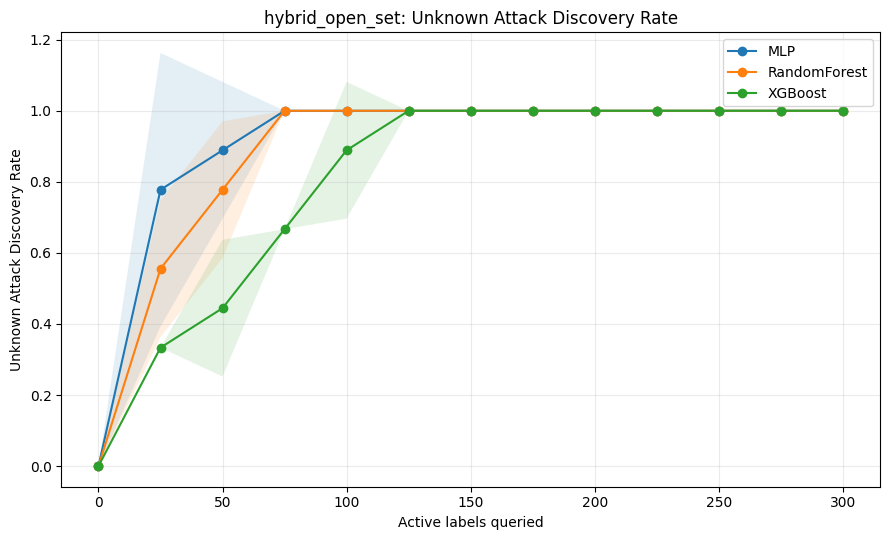

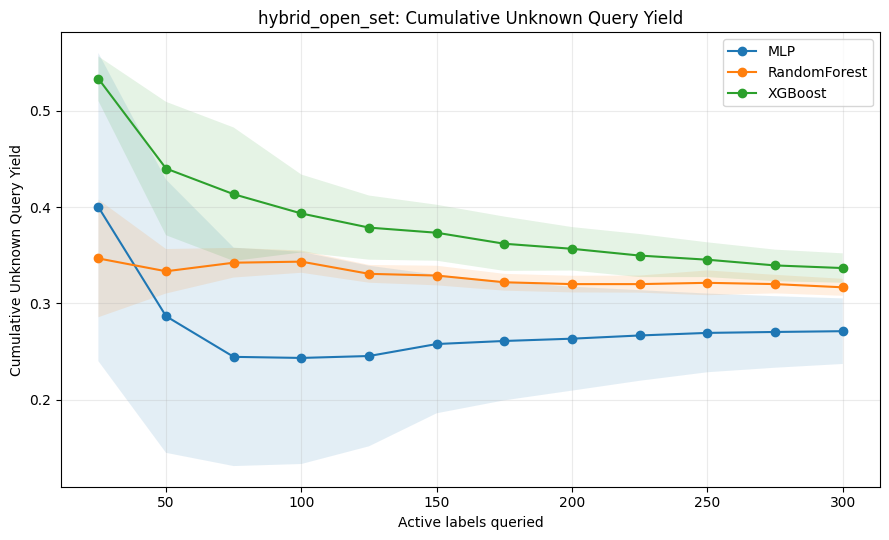

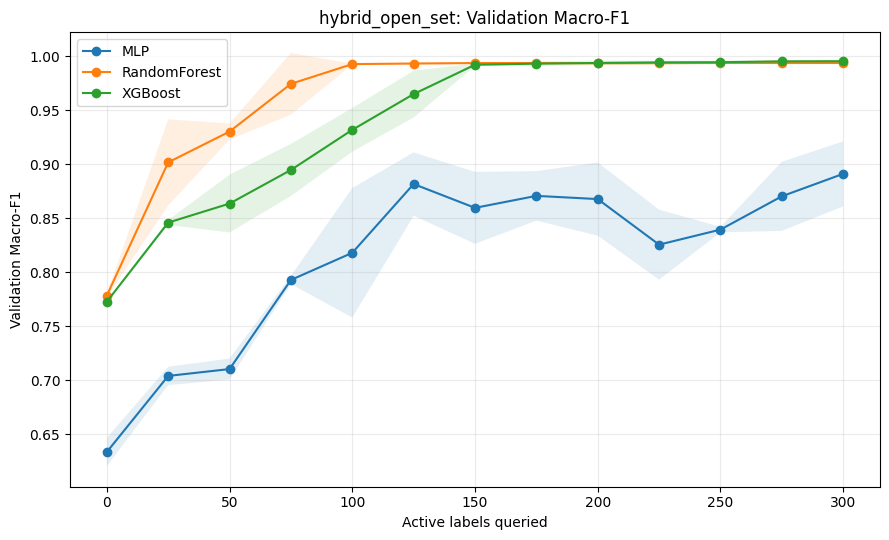

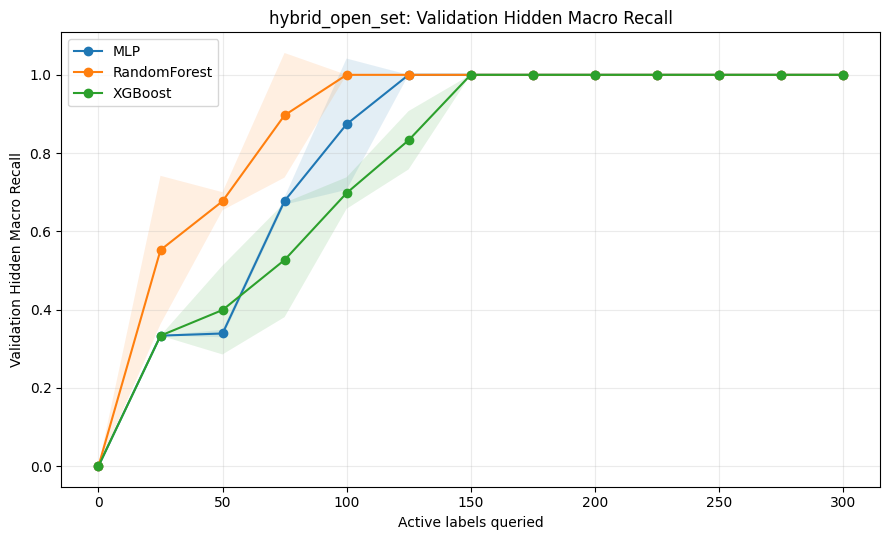

In [23]:
# ============================================================
# 23. Learning/discovery curves by model and strategy
# ============================================================

def plot_cross_model_curve(
    strategy,
    metric,
    ylabel,
    filename,
):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    subset = round_metrics_df[
        round_metrics_df["strategy"].eq(strategy)
    ]

    for model_name, g in subset.groupby("model"):
        plot_data = (
            g.groupby("cumulative_queries")[metric]
            .agg(["mean", "std"])
            .reset_index()
            .sort_values("cumulative_queries")
        )

        ax.plot(
            plot_data["cumulative_queries"],
            plot_data["mean"],
            marker="o",
            label=model_name,
        )

        if len(EXPERIMENT_SEEDS) > 1:
            std = plot_data["std"].fillna(0)

            ax.fill_between(
                plot_data["cumulative_queries"],
                plot_data["mean"] - std,
                plot_data["mean"] + std,
                alpha=0.12,
            )

    ax.set_xlabel("Active labels queried")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{strategy}: {ylabel}")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "plots" / filename,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()


plot_cross_model_curve(
    "hybrid_open_set",
    "uadr",
    "Unknown Attack Discovery Rate",
    "hybrid_uadr_cross_model.png",
)

plot_cross_model_curve(
    "hybrid_open_set",
    "unknown_query_yield_cumulative",
    "Cumulative Unknown Query Yield",
    "hybrid_unknown_query_yield_cross_model.png",
)

plot_cross_model_curve(
    "hybrid_open_set",
    "validation_macro_f1",
    "Validation Macro-F1",
    "hybrid_validation_macro_f1_cross_model.png",
)

plot_cross_model_curve(
    "hybrid_open_set",
    "validation_hidden_macro_recall",
    "Validation Hidden Macro Recall",
    "hybrid_hidden_recall_cross_model.png",
)

In [24]:
# ============================================================
# 24. Hybrid acquisition-channel effectiveness by model
# ============================================================

hybrid_queries = query_log_df[
    query_log_df["strategy"].eq("hybrid_open_set")
].copy()

channel_rows = []

for (model_name, channel), g in hybrid_queries.groupby(
    ["model", "acquisition_channel"]
):
    hidden_count = int(g["is_hidden_attack"].sum())
    total = len(g)

    channel_rows.append({
        "model": model_name,
        "acquisition_channel": channel,
        "queries": total,
        "hidden_queries": hidden_count,
        "hidden_yield": hidden_count / total if total else np.nan,
    })

channel_effectiveness_df = pd.DataFrame(channel_rows)

channel_effectiveness_df.to_csv(
    OUTPUT_DIR / "FINAL_hybrid_channel_effectiveness.csv",
    index=False,
)

display(
    channel_effectiveness_df.sort_values(
        ["model", "hidden_yield"],
        ascending=[True, False],
    )
)

,model,acquisition_channel,queries,hidden_queries,hidden_yield
0,MLP,expansion,231,201,0.870130
3,MLP,uncertainty,288,26,0.090278
1,MLP,novelty,273,17,0.062271
2,MLP,random,108,0,0.000000
4,RandomForest,expansion,231,227,0.982684
7,RandomForest,uncertainty,288,37,0.128472
5,RandomForest,novelty,273,19,0.069597
6,RandomForest,random,108,2,0.018519
8,XGBoost,expansion,231,230,0.995671
11,XGBoost,uncertainty,288,52,0.180556


In [25]:
# ============================================================
# 25. Version-B external-capture benchmark for all three models
# ============================================================

external_summary_rows = []
external_per_class_rows = []

if RUN_EXTERNAL_CAPTURE_BENCHMARK:
    dev_df = model_df[
        model_df[EXTERNAL_SPLIT].eq("development")
    ].reset_index(drop=True)

    ext_df = model_df[
        model_df[EXTERNAL_SPLIT].eq("external_test")
    ].reset_index(drop=True)

    assert set(dev_df["source_file"]).isdisjoint(
        set(ext_df["source_file"])
    )

    ext_pre = make_preprocessor()
    ext_pre.fit(dev_df[BEHAVIOR_FEATURES])

    X_dev = transform_dense(ext_pre, dev_df)
    X_ext = transform_dense(ext_pre, ext_df)

    ext_classes = sorted(
        dev_df[TARGET].astype(str).unique().tolist()
    )

    assert set(
        ext_df[TARGET].astype(str).unique()
    ).issubset(ext_classes)

    y_dev = dev_df[TARGET].astype(str).to_numpy()
    y_ext = ext_df[TARGET].astype(str).to_numpy()

    for model_name in MODELS:
        for seed in EXPERIMENT_SEEDS:
            model, model_classes, _ = train_model(
                model_name,
                X_dev,
                y_dev,
                ext_classes,
                seed + 700_001,
            )

            pred = predict_labels(
                model_name,
                model,
                model_classes,
                X_ext,
            )

            metrics, pc = evaluate_multiclass(
                y_ext,
                pred,
                labels=ext_classes,
            )

            external_summary_rows.append({
                "model": model_name,
                "seed": seed,
                "external_accuracy": metrics["accuracy"],
                "external_macro_precision": metrics["macro_precision"],
                "external_macro_recall": metrics["macro_recall"],
                "external_macro_f1": metrics["macro_f1"],
                "development_rows": len(dev_df),
                "external_rows": len(ext_df),
                "development_files":
                    dev_df["source_file"].nunique(),
                "external_files":
                    ext_df["source_file"].nunique(),
            })

            external_per_class_rows.append(
                pc.assign(
                    model=model_name,
                    seed=seed,
                )
            )

            cleanup_model(model_name, model)

external_summary_df = pd.DataFrame(external_summary_rows)

external_per_class_df = (
    pd.concat(
        external_per_class_rows,
        ignore_index=True,
    )
    if external_per_class_rows
    else pd.DataFrame()
)

external_summary_df.to_csv(
    OUTPUT_DIR / "version_B_all_models_summary.csv",
    index=False,
)

external_per_class_df.to_csv(
    OUTPUT_DIR / "version_B_all_models_per_class.csv",
    index=False,
)

if len(external_summary_df):
    external_aggregate_df = (
        external_summary_df
        .groupby("model")
        .agg(
            external_accuracy_mean=("external_accuracy", "mean"),
            external_accuracy_std=("external_accuracy", "std"),
            external_macro_f1_mean=("external_macro_f1", "mean"),
            external_macro_f1_std=("external_macro_f1", "std"),
        )
        .reset_index()
    )

    external_aggregate_df.to_csv(
        OUTPUT_DIR / "FINAL_version_B_cross_model.csv",
        index=False,
    )

    display(external_aggregate_df)

,model,external_accuracy_mean,external_accuracy_std,external_macro_f1_mean,external_macro_f1_std
0,MLP,0.878479,0.038797,0.841809,0.054175
1,RandomForest,0.919525,0.000487,0.888653,0.000643
2,XGBoost,0.924351,0.000107,0.884457,0.000149


In [26]:
# ============================================================
# 26. Final paper-ready cross-model summary
# ============================================================

def mean_sd(series, digits=3):
    x = pd.to_numeric(
        series,
        errors="coerce",
    ).dropna()

    if len(x) == 0:
        return "N/A"

    sd = (
        x.std(ddof=1)
        if len(x) > 1
        else 0.0
    )

    return (
        f"{x.mean():.{digits}f} "
        f"± {sd:.{digits}f}"
    )


hybrid_seed_df = summary_df[
    summary_df["strategy"].eq("hybrid_open_set")
].copy()

paper_rows = []

for model_name in MODELS:
    g = hybrid_seed_df[
        hybrid_seed_df["model"].eq(model_name)
    ]

    successful = g[
        g["full_discovery_success"]
    ]

    ext_g = (
        external_summary_df[
            external_summary_df["model"].eq(model_name)
        ]
        if len(external_summary_df)
        else pd.DataFrame()
    )

    paper_rows.append({
        "Model": model_name,
        "UADR": mean_sd(g["uadr"]),
        "Full Discovery":
            f"{int(g['full_discovery_success'].sum())}/{len(g)}",
        "Labels to Full Discovery":
            mean_sd(successful["labels_to_full_discovery"])
            if len(successful)
            else "N/A",
        "Unknown Query Yield":
            mean_sd(g["unknown_query_yield"]),
        "Accuracy":
            mean_sd(g["test_accuracy"]),
        "Macro-F1":
            mean_sd(g["test_macro_f1"]),
        "Hidden Macro Recall":
            mean_sd(g["test_hidden_macro_recall"]),
        "Teardrop Recall":
            mean_sd(g["test_teardrop_recall"]),
        "ACKPFlood Precision":
            mean_sd(g["test_ackpflood_precision"]),
        "ACKPFlood Recall":
            mean_sd(g["test_ackpflood_recall"]),
        "ACKFlood Recall":
            mean_sd(g["test_ackflood_recall"]),
        "ACK Pair Macro-F1":
            mean_sd(g["test_ack_pair_macro_f1"]),
        "Representation Redundancy":
            mean_sd(g["mean_representation_redundancy"]),
        "Group Redundancy":
            mean_sd(g["mean_group_redundancy"]),
        "Binary F1":
            mean_sd(g["test_binary_f1"]),
        "External Macro-F1":
            mean_sd(ext_g["external_macro_f1"])
            if len(ext_g)
            else "N/A",
    })

paper_comparison_df = pd.DataFrame(paper_rows)

paper_comparison_df.to_csv(
    OUTPUT_DIR / "FINAL_paper_ready_hybrid_model_comparison.csv",
    index=False,
)

display(paper_comparison_df)

,Model,UADR,Full Discovery,Labels to Full Discovery,Unknown Query Yield,Accuracy,Macro-F1,Hidden Macro Recall,Teardrop Recall,ACKPFlood Precision,ACKPFlood Recall,ACKFlood Recall,ACK Pair Macro-F1,Representation Redundancy,Group Redundancy,Binary F1,External Macro-F1
0,MLP,1.000 ± 0.000,3/3,25.333 ± 30.892,0.271 ± 0.034,0.894 ± 0.033,0.886 ± 0.032,0.999 ± 0.000,0.996 ± 0.000,0.847 ± 0.130,1.000 ± 0.000,0.921 ± 0.037,0.933 ± 0.048,0.171 ± 0.005,0.019 ± 0.021,0.995 ± 0.000,0.842 ± 0.054
1,RandomForest,1.000 ± 0.000,3/3,57.333 ± 15.044,0.317 ± 0.009,0.993 ± 0.001,0.994 ± 0.001,0.998 ± 0.003,1.000 ± 0.000,1.000 ± 0.000,0.993 ± 0.008,0.985 ± 0.002,0.991 ± 0.003,0.178 ± 0.005,0.021 ± 0.008,0.998 ± 0.001,0.889 ± 0.001
2,XGBoost,1.000 ± 0.000,3/3,102.333 ± 13.577,0.337 ± 0.015,0.994 ± 0.001,0.995 ± 0.001,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,0.987 ± 0.002,0.995 ± 0.000,0.680 ± 0.006,0.000 ± 0.000,0.998 ± 0.001,0.884 ± 0.000


In [27]:
# ============================================================
# 27. Final target checklist per model
# ============================================================

target_specs = [
    ("UADR", "uadr", 1.00, ">="),
    ("Macro-F1", "test_macro_f1", 0.73, ">="),
    ("Hidden Macro Recall", "test_hidden_macro_recall", 0.70, ">="),
    ("Land Recall", "test_land_recall", 0.90, ">="),
    ("Teardrop Recall", "test_teardrop_recall", 0.90, ">="),
    ("ACKPFlood Precision", "test_ackpflood_precision", 0.60, ">="),
    ("ACKPFlood Recall", "test_ackpflood_recall", 0.60, ">="),
    ("ACKFlood Recall", "test_ackflood_recall", 0.65, ">="),
    ("ACK Pair Macro-F1", "test_ack_pair_macro_f1", 0.65, ">="),
    ("Unknown Query Yield", "unknown_query_yield", 0.15, ">="),
    ("Representation Redundancy", "mean_representation_redundancy", 0.60, "<"),
    ("Binary F1", "test_binary_f1", 0.98, ">="),
    ("Accuracy", "test_accuracy", 0.80, ">="),
]

check_rows = []

for model_name in MODELS:
    g = hybrid_seed_df[
        hybrid_seed_df["model"].eq(model_name)
    ]

    for label, col, target, direction in target_specs:
        observed = g[col].mean()

        passed = (
            observed >= target
            if direction == ">="
            else observed < target
        )

        check_rows.append({
            "model": model_name,
            "metric": label,
            "observed_mean": observed,
            "target": target,
            "direction": direction,
            "status": "PASS" if passed else "BELOW TARGET",
        })

    full_rate = g["full_discovery_success"].mean()
    successful = g[g["full_discovery_success"]]
    labels_mean = successful[
        "labels_to_full_discovery"
    ].mean() if len(successful) else np.nan

    check_rows.append({
        "model": model_name,
        "metric": "Labels to Full Discovery",
        "observed_mean": labels_mean,
        "target": 300,
        "direction": "<=",
        "status": (
            "PASS"
            if full_rate == 1.0
            and np.isfinite(labels_mean)
            and labels_mean <= 300
            else "NOT ACHIEVED IN ALL RUNS"
        ),
    })

target_checklist_df = pd.DataFrame(check_rows)

target_checklist_df.to_csv(
    OUTPUT_DIR / "FINAL_target_checklist_all_models.csv",
    index=False,
)

display(target_checklist_df)

,model,metric,observed_mean,target,direction,status
0,MLP,UADR,1.000000,1.00,>=,PASS
1,MLP,Macro-F1,0.886161,0.73,>=,PASS
2,MLP,Hidden Macro Recall,0.998594,0.70,>=,PASS
3,MLP,Land Recall,1.000000,0.90,>=,PASS
4,MLP,Teardrop Recall,0.995781,0.90,>=,PASS
5,MLP,ACKPFlood Precision,0.846900,0.60,>=,PASS
6,MLP,ACKPFlood Recall,1.000000,0.60,>=,PASS
7,MLP,ACKFlood Recall,0.921333,0.65,>=,PASS
8,MLP,ACK Pair Macro-F1,0.932972,0.65,>=,PASS
9,MLP,Unknown Query Yield,0.271111,0.15,>=,PASS


In [ ]:
# ============================================================
# 28. Save limitation, frozen config, and ZIP all outputs
# ============================================================

limitation_statement = (
    "land, ackpflood, and teardrop each have only one independent source "
    "capture in the supplied dataset. Therefore, the experiment evaluates "
    "their discovery and subsequent learning within the Active Learning "
    "setting, but cannot establish source-file-disjoint generalization for "
    "those hidden classes from this dataset alone."
)

with open(
    OUTPUT_DIR / "FINAL_data_limitation.txt",
    "w",
    encoding="utf-8",
) as f:
    f.write(limitation_statement)

experiment_config = {
    "run_mode": RUN_MODE,
    "models": MODELS,
    "strategies": STRATEGIES,
    "seeds": EXPERIMENT_SEEDS,
    "initial_per_known_class": INITIAL_PER_KNOWN_CLASS,
    "label_budget": LABEL_BUDGET,
    "query_batch_size": QUERY_BATCH_SIZE,
    "hidden_classes": HIDDEN_CLASSES,
    "known_classes": KNOWN_CLASSES,
    "hybrid_quotas": HYBRID_QUOTAS,
    "strict_cosine_similarity_threshold":
        STRICT_COSINE_SIM_THRESHOLD,
    "score_weights": {
        "uncertainty": BASE_W_UNCERTAINTY,
        "novelty": BASE_W_NOVELTY,
        "density": BASE_W_DENSITY,
    },
    "MLP": {
        "hidden_units": list(MLP_HIDDEN_UNITS),
        "embedding_dim": MLP_EMBEDDING_DIM,
        "dropout": MLP_DROPOUT,
        "learning_rate": MLP_LR,
        "weight_decay": MLP_WEIGHT_DECAY,
        "focal_gamma": MLP_FOCAL_GAMMA,
        "mc_passes": MLP_MC_PASSES,
    },
    "RandomForest": {
        "n_estimators": RF_N_ESTIMATORS,
        "max_depth": RF_MAX_DEPTH,
        "max_features": RF_MAX_FEATURES,
        "criterion": RF_CRITERION,
    },
    "XGBoost": {
        "n_estimators": XGB_N_ESTIMATORS,
        "max_depth": XGB_MAX_DEPTH,
        "learning_rate": XGB_LEARNING_RATE,
        "subsample": XGB_SUBSAMPLE,
        "colsample_bytree": XGB_COLSAMPLE_BYTREE,
    },
    "class_weighting": {
        "effective_number_beta": EFFECTIVE_NUMBER_BETA,
        "max_class_weight": MAX_CLASS_WEIGHT,
    },
    "primary_split": PRIMARY_SPLIT,
    "external_split": EXTERNAL_SPLIT,
}

with open(
    OUTPUT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(experiment_config, f, indent=2)

print("DATA LIMITATION:")
print(limitation_statement)

zip_base = WORK_ROOT / "combined_hybrid_open_set_mlp_rf_xgb_results"
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    OUTPUT_DIR,
)

print("\nAll outputs saved to:", OUTPUT_DIR)
print("ZIP:", zip_path)
print(
    "ZIP size MB:",
    round(Path(zip_path).stat().st_size / (1024 ** 2), 2),
)

try:
    from IPython.display import FileLink, display

    old_cwd = os.getcwd()
    os.chdir(WORK_ROOT)
    display(FileLink(Path(zip_path).name))
    os.chdir(old_cwd)
except Exception:
    pass

# Final interpretation rules

Use the combined notebook outputs as follows:

1. Compare **MLP, Random Forest, and XGBoost Hybrid Open-Set results** using the same seeds and same final test split.
2. Report mean ± SD across the three seeds.
3. Keep **UADR/discovery cost** separate from **hidden-class recall/F1**.
4. Report ACKPFlood precision and recall together.
5. Report ACKFlood recall and ACK-pair Macro-F1.
6. Report unknown-query yield and diversity alongside classification.
7. Report Version-B external Macro-F1 separately.
8. Do not treat cross-model representation redundancy as perfectly identical geometry; the representations differ by model.
9. Do not change hyperparameters after inspecting the final sealed test results.
10. Preserve the single-capture limitation for `land`, `ackpflood`, and `teardrop`.

This notebook deliberately does **not** calculate an arbitrary weighted "overall score." Instead, it provides the raw comparable metrics and identifies the leader for each criterion.